## Model Training for the IBM Churn Dataset

In [33]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline  
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    roc_auc_score,
    recall_score,
    f1_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

In [34]:
df = pd.read_csv("../datasets/processed/feature_engineered_telco.csv")
df.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,...,Streaming TV,Streaming Movies,Paperless Billing,Payment Method,Monthly Charges,Churn Value,Tenure Bucket,Total Services,Is Month-to-Month,High Monthly Charges
0,Male,No,No,No,2,Yes,No,DSL,1,1,...,0,0,Yes,Mailed check,53.85,1,low,2,1,0
1,Female,No,No,Yes,2,Yes,No,Fiber optic,0,0,...,0,0,Yes,Electronic check,70.70,1,low,0,1,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,0,0,...,1,1,Yes,Electronic check,99.65,1,low,3,1,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,0,0,...,1,1,Yes,Electronic check,104.80,1,medium,4,1,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,0,1,...,1,1,Yes,Bank transfer (automatic),103.70,1,high,4,1,1


In [35]:
X = df.drop(columns=["Churn Value"])
y = df["Churn Value"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train churn ratio:", y_train.mean())
print("Test churn ratio:", y_test.mean())

Train churn ratio: 0.2657777777777778
Test churn ratio: 0.2658137882018479


In [36]:
df.columns

Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Churn Value', 'Tenure Bucket',
       'Total Services', 'Is Month-to-Month', 'High Monthly Charges'],
      dtype='str')

In [37]:
continuous_cols = [
    "Tenure Months",
    "Monthly Charges"
]

binary_numeric_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Total Services",
    "Is Month-to-Month",
    "High Monthly Charges"
]

categorical_cols = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Paperless Billing",
    "Payment Method",
    "Tenure Bucket"
]


In [38]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cont", StandardScaler(), continuous_cols),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols),
        ("bin", "passthrough", binary_numeric_cols)
    ]
)

In [39]:
roc_auc_scores = []
recall = []
f1 = []
accuracy = []

In [40]:
def evaluate_model(model, pipeline):

    pipeline.fit(X_train, y_train)

    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    y_pred = pipeline.predict(X_test)

    roc_auc_val = roc_auc_score(y_test, y_pred_proba)
    recall_val = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    accuracy_val = accuracy_score(y_test, y_pred)

    roc_auc_scores.append(roc_auc_val)
    recall.append(recall_val)
    f1.append(f1_val)
    accuracy.append(accuracy_val)

    print(f"Model: {model}")
    print("~"*50)
    print(f"ROC AUC Score: {roc_auc_val:.4f}")
    print("~"*50)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    print("~"*50)

    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix for {model}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## Logistic Regression

Model: Logistic Regression
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ROC AUC Score: 0.8399
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


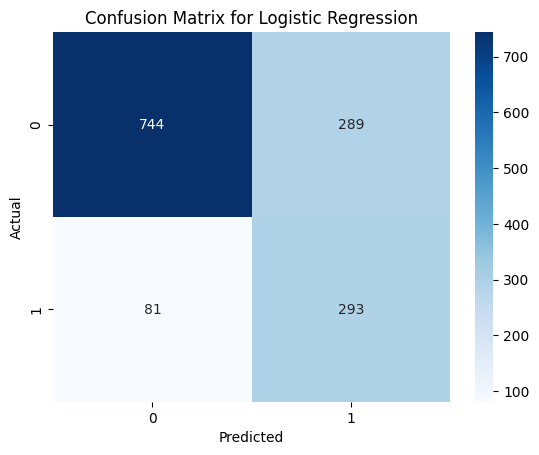

In [41]:
log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=RANDOM_STATE
    ))
])

evaluate_model("Logistic Regression", log_pipeline)

## Random Forest

Model: Random Forest
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ROC AUC Score: 0.8242
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.88      0.85      1033
           1       0.59      0.49      0.53       374

    accuracy                           0.77      1407
   macro avg       0.71      0.68      0.69      1407
weighted avg       0.76      0.77      0.77      1407

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


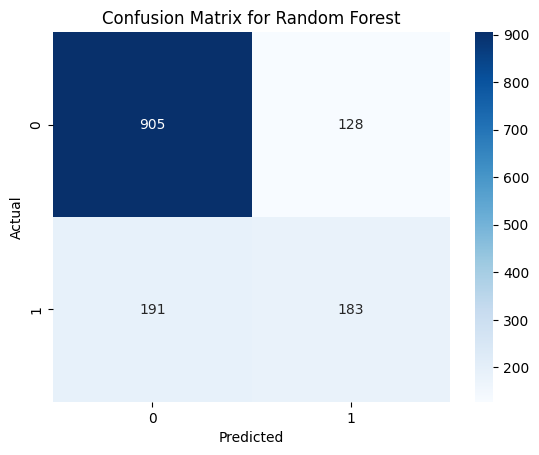

In [42]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

evaluate_model("Random Forest", rf_pipeline)

Model: Gradient Boosting
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ROC AUC Score: 0.8485
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


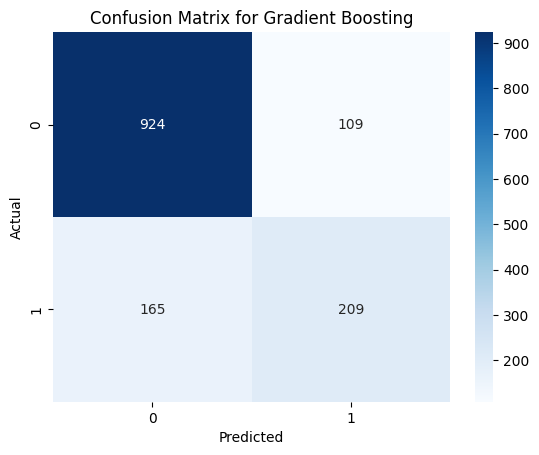

In [43]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ))
])

evaluate_model("Gradient Boosting", gb_pipeline)

Model: KNN
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ROC AUC Score: 0.7832
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.85      0.84      1033
           1       0.57      0.55      0.56       374

    accuracy                           0.77      1407
   macro avg       0.71      0.70      0.70      1407
weighted avg       0.77      0.77      0.77      1407

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


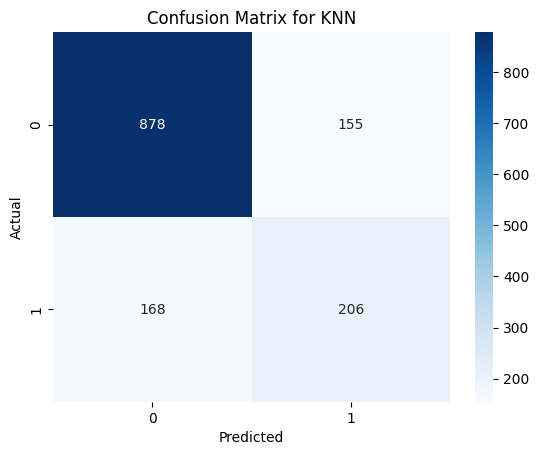

In [44]:
knn_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", KNeighborsClassifier(n_neighbors=5))
])

evaluate_model("KNN", knn_pipeline)

Model: Decision Tree
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ROC AUC Score: 0.6513
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.83      0.82      1033
           1       0.50      0.48      0.49       374

    accuracy                           0.73      1407
   macro avg       0.66      0.65      0.65      1407
weighted avg       0.73      0.73      0.73      1407

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


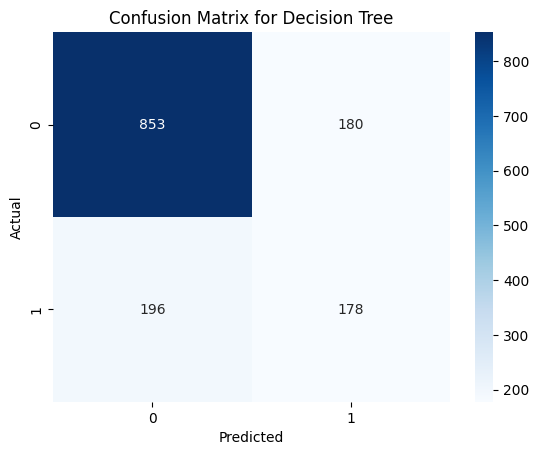

In [45]:
dt_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

evaluate_model("Decision Tree", dt_pipeline)

Model: Naive Bayes
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
ROC AUC Score: 0.8314
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.75      0.76      1407

~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~


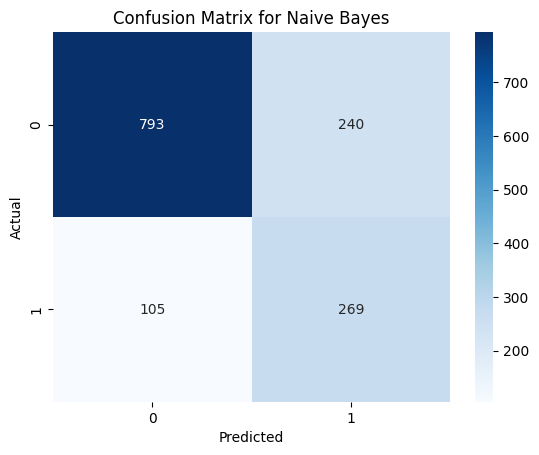

In [46]:
nb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GaussianNB())
])

evaluate_model("Naive Bayes", nb_pipeline)

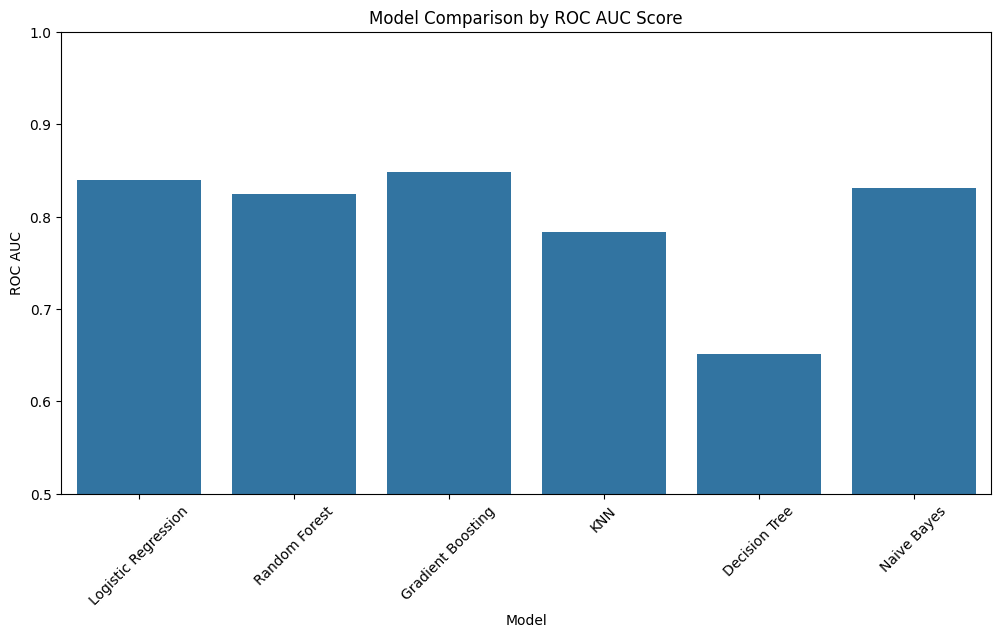

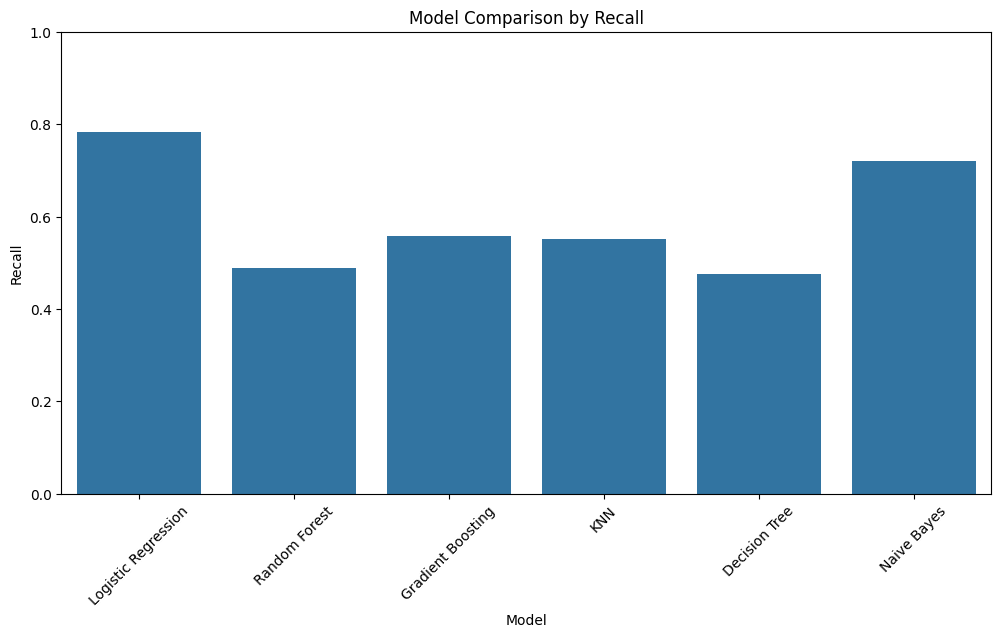

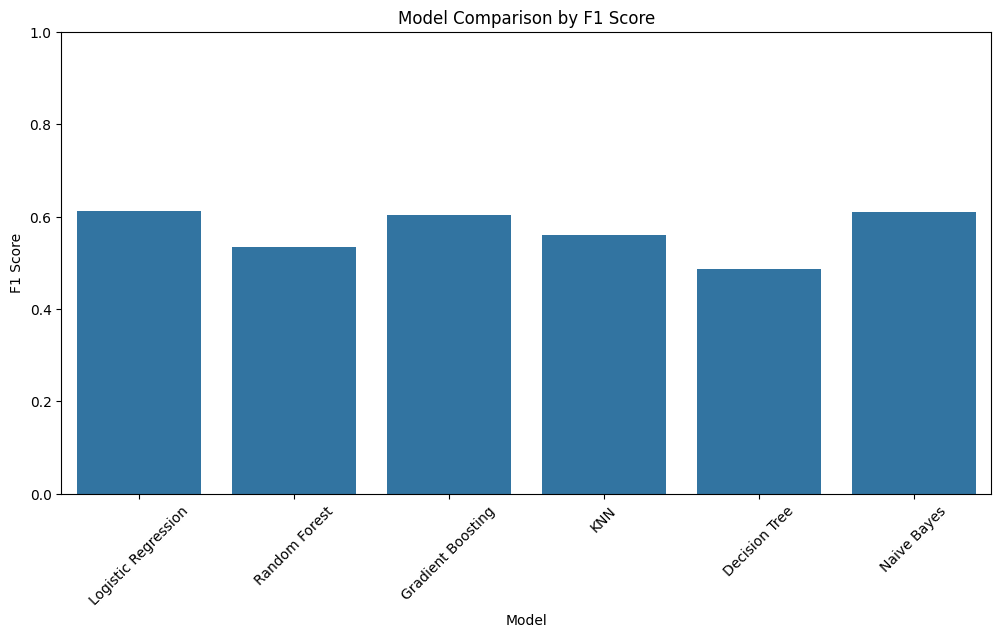

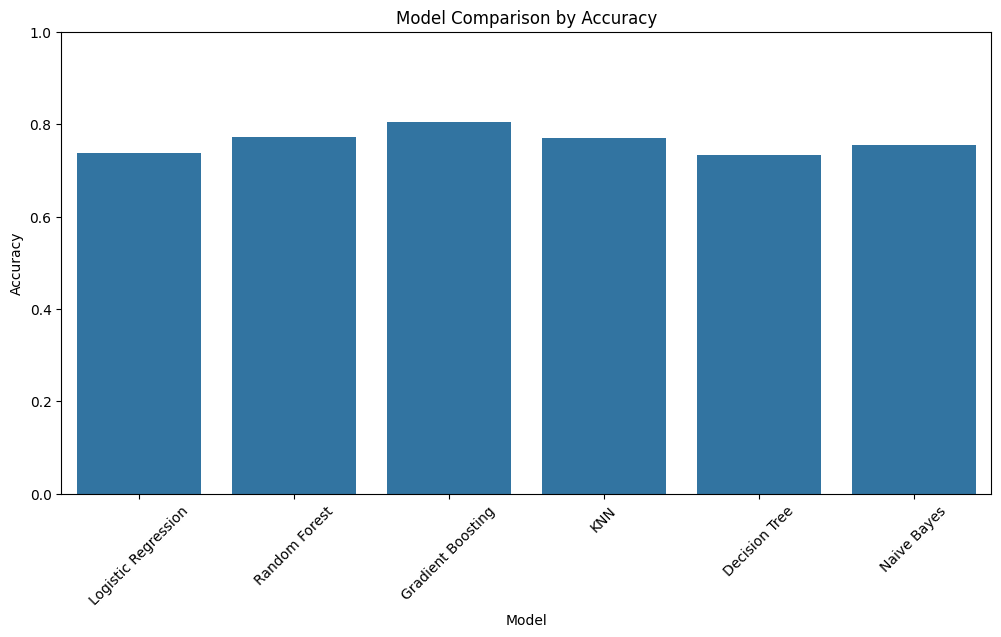

In [47]:
# plotting model comparisons by roc_auc_score, recall, f1, and accuracy

models = ["Logistic Regression", "Random Forest", "Gradient Boosting", "KNN", "Decision Tree", "Naive Bayes"]
metrics_df = pd.DataFrame({
    "Model": models,
    "ROC AUC": roc_auc_scores,
    "Recall": recall,
    "F1 Score": f1,
    "Accuracy": accuracy
})

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="ROC AUC", data=metrics_df)
plt.title("Model Comparison by ROC AUC Score")
plt.xticks(rotation=45)
plt.ylim(0.5, 1)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Recall", data=metrics_df)
plt.title("Model Comparison by Recall")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="F1 Score", data=metrics_df)
plt.title("Model Comparison by F1 Score")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(12, 6))
sns.barplot(x="Model", y="Accuracy", data=metrics_df)
plt.title("Model Comparison by Accuracy")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()


# Best Models here: 

- Logistic Regression has highest recall (0.78) and solid roc-auc (0.8399) with a decent f1 (0.61) 
- Gradient Boosting has the best roc-auc score (0.8485) and the highest accuracy with a balanced precision/recall but recall is only 0.56

Here we can threshold tune both the models and whichever performs better, we can choose for further tuning.

In [48]:
import numpy as np

log_pipeline.fit(X_train, y_train)
log_proba = log_pipeline.predict_proba(X_test)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)

print("LOGISTIC THRESHOLD SWEEP")
print("Threshold | Recall | Precision | F1")

log_recall = []
log_precision = []
log_f1 = []

for t in thresholds:
    y_pred_thresh = (log_proba >= t).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    
    recall = report["1"]["recall"]
    precision = report["1"]["precision"]
    f1 = report["1"]["f1-score"]

    log_recall.append(recall)
    log_precision.append(precision)
    log_f1.append(f1)
    
    print(f"{t:.2f}      | {recall:.3f}  | {precision:.3f}   | {f1:.3f}")

LOGISTIC THRESHOLD SWEEP
Threshold | Recall | Precision | F1
0.10      | 0.984  | 0.349   | 0.515
0.15      | 0.973  | 0.384   | 0.550
0.20      | 0.955  | 0.405   | 0.568
0.25      | 0.928  | 0.421   | 0.579
0.30      | 0.904  | 0.438   | 0.590
0.35      | 0.874  | 0.451   | 0.595
0.40      | 0.848  | 0.465   | 0.601
0.45      | 0.824  | 0.480   | 0.607
0.50      | 0.783  | 0.503   | 0.613
0.55      | 0.746  | 0.529   | 0.619
0.60      | 0.709  | 0.542   | 0.614
0.65      | 0.682  | 0.584   | 0.629
0.70      | 0.618  | 0.619   | 0.618
0.75      | 0.535  | 0.654   | 0.588
0.80      | 0.439  | 0.672   | 0.531
0.85      | 0.324  | 0.695   | 0.442


In [49]:
gb_pipeline.fit(X_train, y_train)
gb_proba = gb_pipeline.predict_proba(X_test)[:, 1]

print("\nGRADIENT BOOSTING THRESHOLD SWEEP")
print("Threshold | Recall | Precision | F1")

gb_recall = []
gb_precision = []
gb_f1 = []

for t in thresholds:
    y_pred_thresh = (gb_proba >= t).astype(int)
    report = classification_report(y_test, y_pred_thresh, output_dict=True)
    
    recall = report["1"]["recall"]
    precision = report["1"]["precision"]
    f1 = report["1"]["f1-score"]

    gb_recall.append(recall)
    gb_precision.append(precision)
    gb_f1.append(f1)
    
    print(f"{t:.2f}      | {recall:.3f}  | {precision:.3f}   | {f1:.3f}")


GRADIENT BOOSTING THRESHOLD SWEEP
Threshold | Recall | Precision | F1
0.10      | 0.930  | 0.425   | 0.583
0.15      | 0.901  | 0.457   | 0.606
0.20      | 0.850  | 0.481   | 0.614
0.25      | 0.816  | 0.498   | 0.619
0.30      | 0.778  | 0.522   | 0.624
0.35      | 0.733  | 0.552   | 0.630
0.40      | 0.676  | 0.593   | 0.632
0.45      | 0.612  | 0.622   | 0.617
0.50      | 0.559  | 0.657   | 0.604
0.55      | 0.492  | 0.657   | 0.563
0.60      | 0.414  | 0.686   | 0.517
0.65      | 0.332  | 0.717   | 0.453
0.70      | 0.267  | 0.735   | 0.392
0.75      | 0.203  | 0.809   | 0.325
0.80      | 0.158  | 0.881   | 0.268
0.85      | 0.059  | 0.957   | 0.111


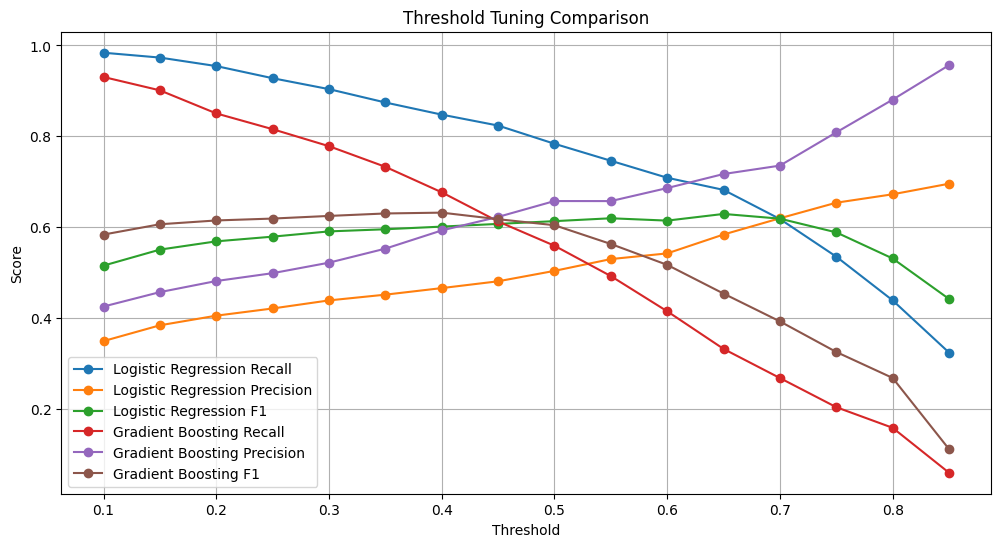

In [50]:
## comparison plot after threshold tuning for logistic regression and gradient boosting

plt.figure(figsize=(12, 6))

plt.plot(thresholds, log_recall, label="Logistic Regression Recall", marker="o")
plt.plot(thresholds, log_precision, label="Logistic Regression Precision", marker="o")
plt.plot(thresholds, log_f1, label="Logistic Regression F1", marker="o")

plt.plot(thresholds, gb_recall, label="Gradient Boosting Recall", marker="o")
plt.plot(thresholds, gb_precision, label="Gradient Boosting Precision", marker="o")
plt.plot(thresholds, gb_f1, label="Gradient Boosting F1", marker="o")

plt.title("Threshold Tuning Comparison")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.legend()
plt.grid()
plt.show()

## Better Overall Model: Gradient Boosting

- Better ranking ability (ROC-AUC 0.8485 vs 0.8399)
- Slightly better F1 at optimal threshold
- Better precision–recall curve shape
- More capacity for improvement with tuning

Now we can perform hyperparameter tuning on GB.


In [51]:
param_dist = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__max_depth": [2, 3, 4, 5],
    "model__subsample": [0.6, 0.8, 1.0],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [52]:
gb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

In [53]:
random_search = RandomizedSearchCV(
    estimator=gb_pipeline,
    param_distributions=param_dist,
    n_iter=40,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

best_gb_model = random_search.best_estimator_
y_pred_proba = best_gb_model.predict_proba(X_test)[:, 1]
roc_auc_val = roc_auc_score(y_test, y_pred_proba)


Fitting 5 folds for each of 40 candidates, totalling 200 fits


In [54]:
print("Best ROC-AUC (CV):", random_search.best_score_)
print("Best Params:", random_search.best_params_)

Best ROC-AUC (CV): 0.8621462178204993
Best Params: {'model__subsample': 0.6, 'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 4, 'model__learning_rate': 0.01}


In [55]:
best_gb = random_search.best_estimator_

y_pred = best_gb.predict(X_test)
y_proba = best_gb.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Test ROC-AUC: 0.8478563034824068
              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1033
           1       0.66      0.56      0.61       374

    accuracy                           0.81      1407
   macro avg       0.76      0.73      0.74      1407
weighted avg       0.80      0.81      0.80      1407



## Logistic Tuning (making sure if GB really is the best)

In [56]:
log_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=2000,
        random_state=RANDOM_STATE
    ))
])

param_dist_log = {
    "model__C": np.logspace(-3, 3, 20),
    "model__penalty": ["l1", "l2"],
    "model__solver": ["liblinear", "saga"]
}

random_search_log = RandomizedSearchCV(
    estimator=log_pipeline,
    param_distributions=param_dist_log,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    verbose=2,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

random_search_log.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


c:\Users\kavis\Desktop\Telco_Customer_Churn\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
c:\Users\kavis\Desktop\Telco_Customer_Churn\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__C': array([1.0000...00000000e+03]), 'model__penalty': ['l1', 'l2'], 'model__solver': ['liblinear', 'saga']}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchang

In [57]:
print("Best CV ROC-AUC:", random_search_log.best_score_)
print("Best Params:", random_search_log.best_params_)

best_log = random_search_log.best_estimator_

y_pred = best_log.predict(X_test)
y_proba = best_log.predict_proba(X_test)[:, 1]

print("Test ROC-AUC:", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

Best CV ROC-AUC: 0.8587903989893674
Best Params: {'model__solver': 'liblinear', 'model__penalty': 'l1', 'model__C': np.float64(0.1623776739188721)}
Test ROC-AUC: 0.8413245259381584
              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.74      1407
   macro avg       0.70      0.75      0.71      1407
weighted avg       0.80      0.74      0.75      1407



In [58]:
'--- IGNORE ---'

'--- IGNORE ---'

| Model               | Test ROC-AUC | Recall | F1   |
| ------------------- | ------------ | ------ | ---- |
| Logistic (baseline) | 0.8399       | 0.78   | 0.61 |
| Logistic (tuned)    | 0.8413       | 0.78   | 0.61 |
| GB (baseline)       | 0.8485       | 0.56   | 0.60 |
| GB (tuned)          | 0.8479       | 0.56   | 0.61 |


Model we're going with: Gradient Boosting + optimized threshold

- Slightly better ROC-AUC

- Slightly better F1 potential

- Controlled complexity

- No severe overfitting

- Well-regularized tuning outcome

But, Logisitc performs nearly as well and is a strong fallback.



optimal parameters from random search for gradient boosting:

{'model__subsample': 0.6, 'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_depth': 4, 'model__learning_rate': 0.01}